# Importing Modules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score, recall_score, confusion_matrix, f1_score, roc_curve,auc
import warnings
from sklearn.exceptions import FitFailedWarning
warnings.simplefilter('ignore', FitFailedWarning)
from imblearn.over_sampling import RandomOverSampler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis


# Importing Dataset

In [2]:
# The file path with forward slashes is recommended for stability
file_path = "C:/Users/Anjali Singh/Downloads/Employee_Attrition_Prediction-main/WA_Fn-UseC_-HR-Employee-Attrition.csv"

# Load the dataset using the pyarrow engine for faster performance
df = pd.read_csv(file_path, engine='pyarrow')

In [3]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


# No Missing Values

In [4]:
df.isna().any().any()

np.False_

# Encoding Categorical Values

In [5]:
#Columns with string values
categorical_column = ['Attrition', 'BusinessTravel', 'Department','Gender', 'JobRole', 'MaritalStatus', 'OverTime','EducationField']
encoder=LabelEncoder()
df[categorical_column]=df[categorical_column].apply(encoder.fit_transform)

# Seperating into X and y

In [6]:
y=df['Attrition']
X=df.drop(['EmployeeCount','Attrition','EmployeeNumber','Over18','StandardHours'],axis=1)

In [7]:
ros = RandomOverSampler(random_state=42)
X_, y = ros.fit_resample(X,y)
X = pd.DataFrame(X_,columns=X.columns)

# Spliting into Train and Test Sets

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=1)

### Sample Row

In [9]:
X_train.iloc[0].to_dict()

{'Age': 20,
 'BusinessTravel': 2,
 'DailyRate': 1362,
 'Department': 1,
 'DistanceFromHome': 10,
 'Education': 1,
 'EducationField': 3,
 'EnvironmentSatisfaction': 4,
 'Gender': 1,
 'HourlyRate': 32,
 'JobInvolvement': 3,
 'JobLevel': 1,
 'JobRole': 6,
 'JobSatisfaction': 3,
 'MaritalStatus': 2,
 'MonthlyIncome': 1009,
 'MonthlyRate': 26999,
 'NumCompaniesWorked': 1,
 'OverTime': 1,
 'PercentSalaryHike': 11,
 'PerformanceRating': 3,
 'RelationshipSatisfaction': 4,
 'StockOptionLevel': 0,
 'TotalWorkingYears': 1,
 'TrainingTimesLastYear': 5,
 'WorkLifeBalance': 3,
 'YearsAtCompany': 1,
 'YearsInCurrentRole': 0,
 'YearsSinceLastPromotion': 1,
 'YearsWithCurrManager': 1}

# Hyper-parameter Tuning Using Grid Search CV

In [10]:
def tune_hyperparameters(model,X,y):
  param_grid = {"solver":['svd', 'lsqr', 'eigen'], "shrinkage":['auto',0.1,0.01,1,0]}
  grid_search = GridSearchCV(model,param_grid=param_grid,scoring='accuracy')
  grid_search.fit(X,y)
  print("Best Params: ",grid_search.best_params_)
  return grid_search.best_params_

In [11]:
best_params = tune_hyperparameters(LinearDiscriminantAnalysis(),X_train,y_train)
best_params

Best Params:  {'shrinkage': 'auto', 'solver': 'lsqr'}


C:\Users\Anjali Singh\AppData\Roaming\Python\Python313\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [       nan 0.76765854 0.76765854        nan 0.59097261 0.59097261
        nan 0.59503058 0.59503058        nan 0.57417609 0.57417609
        nan 0.7612834  0.7612834 ]
  warnings.warn(


{'shrinkage': 'auto', 'solver': 'lsqr'}

# Performing Linear Discrimant Analysis

In [12]:
def train_predict_evaluate(model,X_train,y_train,X_test):
  model.fit(X_train,y_train)
  y_pred = model.predict(X_test)

  print("Accuracy: ",accuracy_score(y_test,y_pred))
  print("Precision: ",precision_score(y_test,y_pred,zero_division=0))
  print("Recall: ",recall_score(y_test,y_pred,zero_division=0))
  print("F1 Score: ",f1_score(y_test,y_pred,zero_division=0))
  print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred))

  
  fpr,tpr,thresholds = roc_curve(y_test,y_pred)
  plt.plot(fpr, tpr,color='green',label='ROC curve (area = %0.2f)' % auc(fpr,tpr))
  plt.plot([0, 1], [0, 1], color='orange', linestyle='--')
  plt.xlabel("False Positive Rate")
  plt.ylabel("True Positive Rate")
  plt.title("ROC Curve")
  plt.legend(loc="lower right")
  plt.show()

Accuracy:  0.7594594594594595
Precision:  0.7727272727272727
Recall:  0.7766497461928934
F1 Score:  0.7746835443037975
Confusion Matrix:
 [[256  90]
 [ 88 306]]


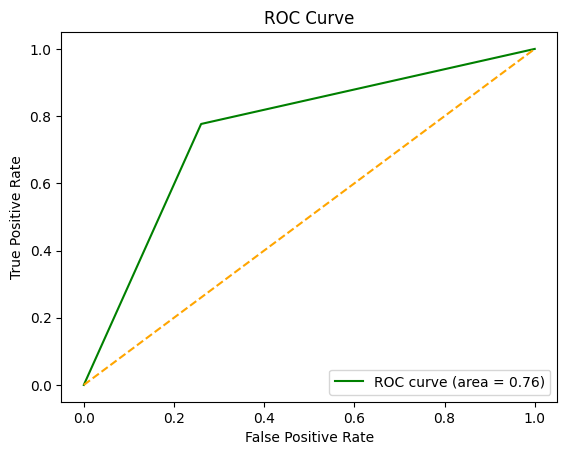

In [13]:
train_predict_evaluate(LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr'),X_train,y_train,X_test)

# K-Fold Cross Validation

In [14]:
def cross_validation(model,X,y):
  scores = cross_validate(model, X, y, cv=5,scoring=('accuracy','precision','recall','f1'))

  metrics = []
  metrics.append(np.mean(scores['test_accuracy']))
  metrics.append(np.mean(scores['test_precision']))
  metrics.append(np.mean(scores['test_recall']))
  metrics.append(np.mean(scores['test_f1']))

  print("Accuracy: ",metrics[0])
  print("Precision: ",metrics[1])
  print("Recall: ",metrics[2])
  print("F1 Score: ",metrics[3])

  return metrics

In [15]:
metrics = []

In [16]:
metrics.append(cross_validation(LinearDiscriminantAnalysis(**best_params),X,y))

Accuracy:  0.7631751402222202
Precision:  0.7529061663247458
Recall:  0.7850926565945822
F1 Score:  0.7682790579917442


# Performance

In [17]:
mdf = pd.DataFrame(metrics,columns=["Accuracy","Precision","Recall","F1 Score"])
mdf.head()

,Accuracy,Precision,Recall,F1 Score
0,0.763175,0.752906,0.785093,0.768279
